# Simulation 2 Retrieval-Selectivity Figure

> Generate the focused Simulation 2 figure for retrieval selectivity.

This notebook holds the post-reminder task-encoding condition fixed and varies retrieval selectivity with or without start-of-list context reinstatement.
It also adds a rejected-sample recovery panel using the same fixed encoding condition.
Panels show phase-resolved recall, full-list lag-CRP, and off-target recovery in the same visual grammar as Figures 2 and 3.


In [1]:
import csv
import os
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from jax import random
from jaxcmr.analyses.crp import simple_crp
from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root
from jaxcmr.plotting import plot_data

from selective_interference_v2 import (
    PHASE_COLORS,
    Paradigm,
    add_phase_bands,
    light_to_dark_colors,
    load_fit_params,
    make_factory,
    make_is_emotional,
    make_is_target,
    prepare_sweep,
    run_sweep,
    save_figure,
    split_scales_for_cache,
    standard_remap,
)

warnings.filterwarnings("ignore")

In [2]:
# --- sweep configuration ---
PROJECT_ROOT = ""
FIT_PATH = "results/fits/Dupertuys2026_eCMR_source_only_phi_no_shared_support_best_of_1.json"
FIGURE_DIR = ""
FIGURE_STR = ""
RNG_SEED = 0

SWEEP_PARAM = "tau_scale"
SWEEP_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
SWEEP_XLABEL = "Retrieval\nselectivity"
SWEEP_LABEL_FMT = "{:.2f}"
CRP_MAX_LAG = 5

KAPPA_PARAM = "rejected_recall_drift_scale"
KAPPA_VALUES = [1.0, 0.75, 0.5, 0.25, 0.0]
KAPPA_XLABEL = "Off-target update ($\\kappa$)"

N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
EXPERIMENT_COUNT = 5000
MAX_RECALL = 48

TASK_MCF_SCALE = 2.0
FILM_EMOTIONAL = False
INTERFERENCE_EMOTIONAL = False
CACHE_AFTER = "filler"

BASE_FIXED_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 1.0,
    "reminder_drift_scale": 1.0,
    "interference_mcf_scale": TASK_MCF_SCALE,
    "filler_drift_scale": 1.0,
    "filler_mcf_scale": 1.0,
}

START_CONTEXT_CONDITIONS = {
    "No start-of-list reinstatement": 0.0,
    "With start-of-list reinstatement": 1.0,
}


In [3]:
# Parameters
FIGURE_DIR = "figures"
FIGURE_STR = "simulation2_retrieval_selectivity"


In [4]:
#| output: asis
if PROJECT_ROOT:
    project_root = Path(PROJECT_ROOT)
else:
    project_root = Path(find_project_root())

fit_path = project_root / FIT_PATH
figure_dir = project_root / FIGURE_DIR if FIGURE_DIR else None
sweep_values = np.asarray(SWEEP_VALUES, dtype=float)
kappa_values = np.asarray(KAPPA_VALUES, dtype=float)

params, n_subjects = load_fit_params(fit_path)
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    experiment_count=EXPERIMENT_COUNT,
    max_recall=MAX_RECALL,
)
factory = make_factory(
    is_emotional=make_is_emotional(
        paradigm,
        film_emotional=FILM_EMOTIONAL,
        interference_emotional=INTERFERENCE_EMOTIONAL,
    ),
    is_target=make_is_target(paradigm),
)
rng = random.PRNGKey(RNG_SEED)

Markdown(
    f"Loaded {n_subjects} fit parameter set(s). Running {len(sweep_values)} retrieval-selectivity values "
    f"and {len(kappa_values)} off-target update values for {len(START_CONTEXT_CONDITIONS)} start-context conditions "
    f"with {EXPERIMENT_COUNT} simulated trials per value."
)


Loaded 1 fit parameter set(s). Running 9 retrieval-selectivity values and 5 off-target update values for 2 start-context conditions with 5000 simulated trials per value.

In [5]:
def position_phase_labels(paradigm):
    return (
        ["film"] * paradigm.n_film
        + ["break"] * paradigm.n_break
        + ["task"] * paradigm.n_interference
        + ["filler"] * paradigm.n_filler
    )


def write_rows(path, fieldnames, rows):
    os.makedirs(path.parent, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def condition_slug(condition):
    return condition.lower().replace("-", "_").replace(" ", "_")


def valid_recall_trials(recalls):
    return recalls[recalls[:, 0] > 0]


def full_list_lag_crp(recalls, list_length):
    valid = valid_recall_trials(recalls)
    if valid.shape[0] == 0:
        return np.full(2 * list_length - 1, np.nan)
    return np.asarray(simple_crp(jnp.asarray(valid, dtype=jnp.int32), list_length), dtype=float)


def phase_recall_totals(spc):
    totals = {}
    for phase in sorted(set(position_phase)):
        positions = [idx for idx, value in enumerate(position_phase) if value == phase]
        totals[phase] = float(np.sum(spc[positions]))
    return totals


def off_target_film_return_probability(recalls, n_film):
    numerator = 0
    denominator = 0
    for row in recalls:
        sampled = [int(value) for value in row if value > 0]
        seen_film = set()
        for idx in range(len(sampled) - 1):
            current = sampled[idx]
            next_sample = sampled[idx + 1]
            if 1 <= current <= n_film:
                seen_film.add(current)
                continue
            if len(seen_film) >= n_film:
                continue
            denominator += 1
            if 1 <= next_sample <= n_film:
                numerator += 1
                seen_film.add(next_sample)
    probability = np.nan if denominator == 0 else numerator / denominator
    return probability, denominator, numerator


position_phase = position_phase_labels(paradigm)
n_presented = len(position_phase)
lag_values = np.arange(-(n_presented - 1), n_presented)
crp_display_mask = (lag_values >= -CRP_MAX_LAG) & (lag_values <= CRP_MAX_LAG)


In [6]:
pre_cache_scales, post_cache_scales = split_scales_for_cache(
    BASE_FIXED_SCALES,
    CACHE_AFTER,
)
prepared = prepare_sweep(
    params,
    paradigm,
    factory,
    cache_after=CACHE_AFTER,
    **pre_cache_scales,
)

condition_outputs = {}
recovery_outputs = {}
for condition, start_context_scale in START_CONTEXT_CONDITIONS.items():
    recalls, rng = run_sweep(
        prepared,
        rng,
        **post_cache_scales,
        start_drift_scale=start_context_scale,
        **{SWEEP_PARAM: sweep_values},
    )
    condition_outputs[condition] = np.asarray(recalls)

    recovery_recalls, rng = run_sweep(
        prepared,
        rng,
        **post_cache_scales,
        start_drift_scale=start_context_scale,
        **{KAPPA_PARAM: kappa_values},
    )
    recovery_outputs[condition] = np.asarray(recovery_recalls)


In [7]:
spc_rows = []
crp_rows = []
phase_rows = []
recovery_rows = []
spc_curves = {}
crp_curves = {}
recovery_curves = {}

for condition, recalls_4d in condition_outputs.items():
    spc_curves[condition] = []
    crp_curves[condition] = []
    start_context_scale = START_CONTEXT_CONDITIONS[condition]
    for value_index, value in enumerate(sweep_values):
        raw_recalls = recalls_4d[value_index].reshape(-1, recalls_4d.shape[-1])
        remapped_recalls = np.asarray(
            standard_remap(
                raw_recalls,
                paradigm,
                show_break=True,
            )
        )
        spc = np.asarray(fixed_pres_spc(remapped_recalls, n_presented), dtype=float)
        crp = full_list_lag_crp(remapped_recalls, n_presented)
        totals = phase_recall_totals(spc)

        spc_curves[condition].append(spc)
        crp_curves[condition].append(crp)

        for position, phase in enumerate(position_phase, start=1):
            spc_rows.append({
                "start_context_condition": condition,
                "start_context_scale": start_context_scale,
                "retrieval_selectivity": value,
                "position": position,
                "phase": phase,
                "recall_probability": spc[position - 1],
            })
        for lag, probability in zip(lag_values, crp):
            crp_rows.append({
                "start_context_condition": condition,
                "start_context_scale": start_context_scale,
                "retrieval_selectivity": value,
                "lag": int(lag),
                "conditional_response_probability": probability,
            })
        for phase, total in totals.items():
            phase_rows.append({
                "start_context_condition": condition,
                "start_context_scale": start_context_scale,
                "retrieval_selectivity": value,
                "phase": phase,
                "recall_probability_mass": total,
            })

for condition, recalls_4d in recovery_outputs.items():
    recovery_curves[condition] = []
    start_context_scale = START_CONTEXT_CONDITIONS[condition]
    for value_index, value in enumerate(kappa_values):
        raw_recalls = recalls_4d[value_index].reshape(-1, recalls_4d.shape[-1])
        remapped_recalls = np.asarray(
            standard_remap(
                raw_recalls,
                paradigm,
                show_break=True,
            )
        )
        recovery, denominator, numerator = off_target_film_return_probability(
            remapped_recalls,
            paradigm.n_film,
        )
        recovery_curves[condition].append(recovery)
        recovery_rows.append({
            "start_context_condition": condition,
            "start_context_scale": start_context_scale,
            "kappa": value,
            "film_return_probability": recovery,
            "transition_count": denominator,
            "film_return_count": numerator,
        })


In [8]:
if figure_dir is not None and FIGURE_STR:
    write_rows(
        figure_dir / f"{FIGURE_STR}_spc.csv",
        [
            "start_context_condition",
            "start_context_scale",
            "retrieval_selectivity",
            "position",
            "phase",
            "recall_probability",
        ],
        spc_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_crp.csv",
        [
            "start_context_condition",
            "start_context_scale",
            "retrieval_selectivity",
            "lag",
            "conditional_response_probability",
        ],
        crp_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_phase_totals.csv",
        [
            "start_context_condition",
            "start_context_scale",
            "retrieval_selectivity",
            "phase",
            "recall_probability_mass",
        ],
        phase_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_offtarget_recovery.csv",
        [
            "start_context_condition",
            "start_context_scale",
            "kappa",
            "film_return_probability",
            "transition_count",
            "film_return_count",
        ],
        recovery_rows,
    )


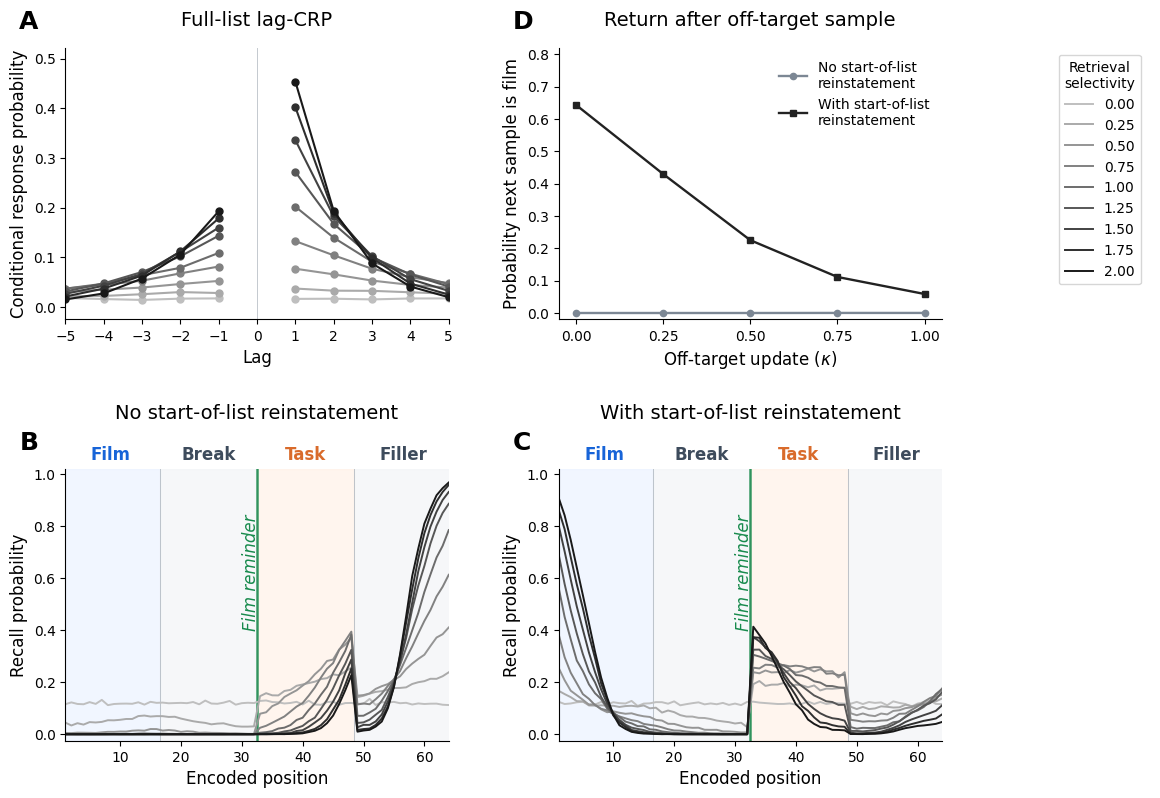

In [9]:
PANEL_LETTER_FONTSIZE = 18
PANEL_TITLE_FONTSIZE = 14
STRUCTURAL_FONTSIZE = 12
SUPPORT_FONTSIZE = 10


CONDITION_TITLES = {
    "No start-of-list reinstatement": "No start-of-list reinstatement",
    "With start-of-list reinstatement": "With start-of-list reinstatement",
}

CONDITION_STYLES = {
    "No start-of-list reinstatement": {
        "color": "#7C8794",
        "marker": "o",
        "label": "No start-of-list\nreinstatement",
    },
    "With start-of-list reinstatement": {
        "color": "#222222",
        "marker": "s",
        "label": "With start-of-list\nreinstatement",
    },
}


def add_panel_label(axis, label, x=-0.12):
    axis.text(
        x,
        1.14,
        label,
        transform=axis.transAxes,
        fontsize=PANEL_LETTER_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left",
    )


def add_phase_boundaries(axis):
    boundaries = np.cumsum([
        paradigm.n_film,
        paradigm.n_break,
        paradigm.n_interference,
    ]) + 0.5
    for boundary in boundaries:
        axis.axvline(boundary, color="#7C8794", linewidth=0.7, alpha=0.45, zorder=1)


def add_reminder_marker(axis):
    reminder_x = paradigm.n_film + paradigm.n_break + 0.5
    axis.axvline(
        reminder_x,
        color=PHASE_COLORS["reminder"],
        linewidth=1.8,
        alpha=0.85,
        zorder=2,
    )
    axis.text(
        reminder_x - 1.05,
        0.62,
        "Film reminder",
        ha="center",
        va="center",
        fontsize=STRUCTURAL_FONTSIZE,
        fontstyle="italic",
        color=PHASE_COLORS["reminder"],
        rotation=90,
        rotation_mode="anchor",
        transform=axis.get_xaxis_transform(),
        clip_on=False,
        zorder=3,
    )


def style_position_axis(axis, ylabel, title):
    add_phase_bands(axis, position_phase, fontsize=STRUCTURAL_FONTSIZE)
    add_phase_boundaries(axis)
    add_reminder_marker(axis)
    axis.set_title(title, fontsize=PANEL_TITLE_FONTSIZE, pad=36)
    axis.set_xlabel("Encoded position", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_ylabel(ylabel, fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(1, n_presented)
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


def plot_spc_panel(axis, condition, label):
    style_position_axis(axis, "Recall probability", CONDITION_TITLES[condition])
    colors = light_to_dark_colors(len(sweep_values))
    positions = np.arange(1, n_presented + 1)
    for color, value, curve in zip(colors, sweep_values, spc_curves[condition]):
        axis.plot(
            positions,
            curve,
            color=color,
            linewidth=1.4,
            label=SWEEP_LABEL_FMT.format(value),
        )
    axis.set_ylim(-0.025, 1.02)
    add_panel_label(axis, label)


def plot_crp_panel(axis, label):
    condition = "With start-of-list reinstatement"
    colors = light_to_dark_colors(len(sweep_values))
    visible_values = []
    for color, value, curve in zip(colors, sweep_values, crp_curves[condition]):
        plot_lags = lag_values[crp_display_mask]
        plot_curve = curve[crp_display_mask].copy()
        plot_curve[plot_lags == 0] = np.nan
        visible_values.append(plot_curve[np.isfinite(plot_curve)])
        before = len(axis.lines)
        plot_data(
            axis,
            jnp.asarray(plot_lags),
            jnp.asarray(plot_curve),
            SWEEP_LABEL_FMT.format(value),
            color,
            draw_ci=False,
        )
        for line in axis.lines[before:]:
            line.set_linewidth(1.5)
    axis.axvline(0, color="#7C8794", linewidth=0.7, alpha=0.45, zorder=1)
    axis.set_title("Full-list lag-CRP", fontsize=PANEL_TITLE_FONTSIZE, pad=16)
    axis.set_xlabel("Lag", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_ylabel("Conditional response probability", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(-CRP_MAX_LAG, CRP_MAX_LAG)
    if visible_values:
        top = np.nanmax(np.concatenate(visible_values))
        axis.set_ylim(-0.025, min(1.0, max(0.20, top * 1.15)))
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    add_panel_label(axis, label)


def plot_recovery_panel(axis, label):
    for condition, values in recovery_curves.items():
        style = CONDITION_STYLES[condition]
        axis.plot(
            kappa_values,
            values,
            color=style["color"],
            marker=style["marker"],
            linewidth=1.7,
            markersize=4.5,
            label=style["label"],
        )
    axis.set_title("Return after off-target sample", fontsize=PANEL_TITLE_FONTSIZE, pad=16)
    axis.set_xlabel(KAPPA_XLABEL, fontsize=STRUCTURAL_FONTSIZE)
    axis.set_ylabel("Probability next sample is film", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(-0.05, 1.05)
    axis.set_ylim(-0.02, 0.82)
    axis.set_xticks(np.linspace(0.0, 1.0, 5))
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.legend(
        loc="upper right",
        fontsize=SUPPORT_FONTSIZE,
        frameon=False,
        handlelength=2.0,
    )
    add_panel_label(axis, label)


fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    2,
    5,
    width_ratios=[1, 1, 1, 1, 0.72],
    height_ratios=[1.0, 1.0],
    hspace=0.55,
    wspace=0.85,
)

axis_a = fig.add_subplot(gs[0, 0:2])
axis_d = fig.add_subplot(gs[0, 2:4])
legend_axis = fig.add_subplot(gs[:, 4])
axis_b = fig.add_subplot(gs[1, 0:2])
axis_c = fig.add_subplot(gs[1, 2:4], sharey=axis_b)
legend_axis.axis("off")

plot_crp_panel(axis_a, "A")
plot_recovery_panel(axis_d, "D")
plot_spc_panel(axis_b, "No start-of-list reinstatement", "B")
plot_spc_panel(axis_c, "With start-of-list reinstatement", "C")
axis_c.tick_params(labelleft=True)

handles, labels = axis_b.get_legend_handles_labels()
legend = legend_axis.legend(
    handles,
    labels,
    title=SWEEP_XLABEL,
    loc="upper left",
    fontsize=SUPPORT_FONTSIZE,
    title_fontsize=SUPPORT_FONTSIZE,
)
legend.get_title().set_multialignment("center")
legend.get_title().set_ha("center")

save_figure(str(figure_dir) if figure_dir is not None else "", FIGURE_STR)


In [10]:
for condition in START_CONTEXT_CONDITIONS:
    low = 0
    high = -1
    film_positions = [i for i, phase in enumerate(position_phase) if phase == "film"]
    task_positions = [i for i, phase in enumerate(position_phase) if phase == "task"]
    low_film = float(np.sum(spc_curves[condition][low][film_positions]))
    high_film = float(np.sum(spc_curves[condition][high][film_positions]))
    low_task = float(np.sum(spc_curves[condition][low][task_positions]))
    high_task = float(np.sum(spc_curves[condition][high][task_positions]))
    low_crp = crp_curves[condition][low]
    high_crp = crp_curves[condition][high]
    near_lag = np.isin(lag_values, [-1, 1])
    print(condition)
    print(f"  Film recall probability mass, selectivity low -> high: {low_film:.2f} -> {high_film:.2f}")
    print(f"  Task recall probability mass, selectivity low -> high: {low_task:.2f} -> {high_task:.2f}")
    print(f"  CRP at lags +/-1, selectivity low -> high: {np.nanmean(low_crp[near_lag]):.3f} -> {np.nanmean(high_crp[near_lag]):.3f}")

for condition in START_CONTEXT_CONDITIONS:
    high = 0
    low = -1
    print(condition)
    print(f"  Film return after off-target sample, kappa 1.00 -> 0.00: {recovery_curves[condition][high]:.3f} -> {recovery_curves[condition][low]:.3f}")


No start-of-list reinstatement
  Film recall probability mass, selectivity low -> high: 1.90 -> 0.00
  Task recall probability mass, selectivity low -> high: 1.94 -> 0.68
  CRP at lags +/-1, selectivity low -> high: 0.016 -> 0.427
With start-of-list reinstatement
  Film recall probability mass, selectivity low -> high: 1.91 -> 4.93
  Task recall probability mass, selectivity low -> high: 1.91 -> 2.46
  CRP at lags +/-1, selectivity low -> high: 0.017 -> 0.323
No start-of-list reinstatement
  Film return after off-target sample, kappa 1.00 -> 0.00: 0.000 -> 0.000
With start-of-list reinstatement
  Film return after off-target sample, kappa 1.00 -> 0.00: 0.059 -> 0.643
